In [33]:
import os
os.chdir('../')

from data_class import Data
import pandas as pd
import numpy as np

title = "X trap freq"
freq_guess = 0.1

files = [
        # "2026-06-30_E.dat", 
        #  "2026-06-30_F.dat",
        # "2026-06-30_H.dat",
        "2026-07-02_E.dat"
         ]

dfs = []

for file in files:
    data = Data(file)
    dfs.append(data.data)

result = pd.concat(dfs, ignore_index=True)


f:\Data\2026\*\*\*\2026-07-02_E.dat


In [34]:
x = result["time"]
y = result["fCtr1"]

p0=[(y.max()-y.min())/2, x.max()-x.min(), freq_guess, 0, y.mean()]

def trap_freq_func(x, a, b, c, d, e):
    return a * np.exp(-x/b) * np.sin(2 * np.pi * c * x + d) + e

from scipy.optimize import curve_fit
popt, pcov = curve_fit(trap_freq_func, x, y, p0=p0)
perr = np.sqrt(np.diag(pcov))


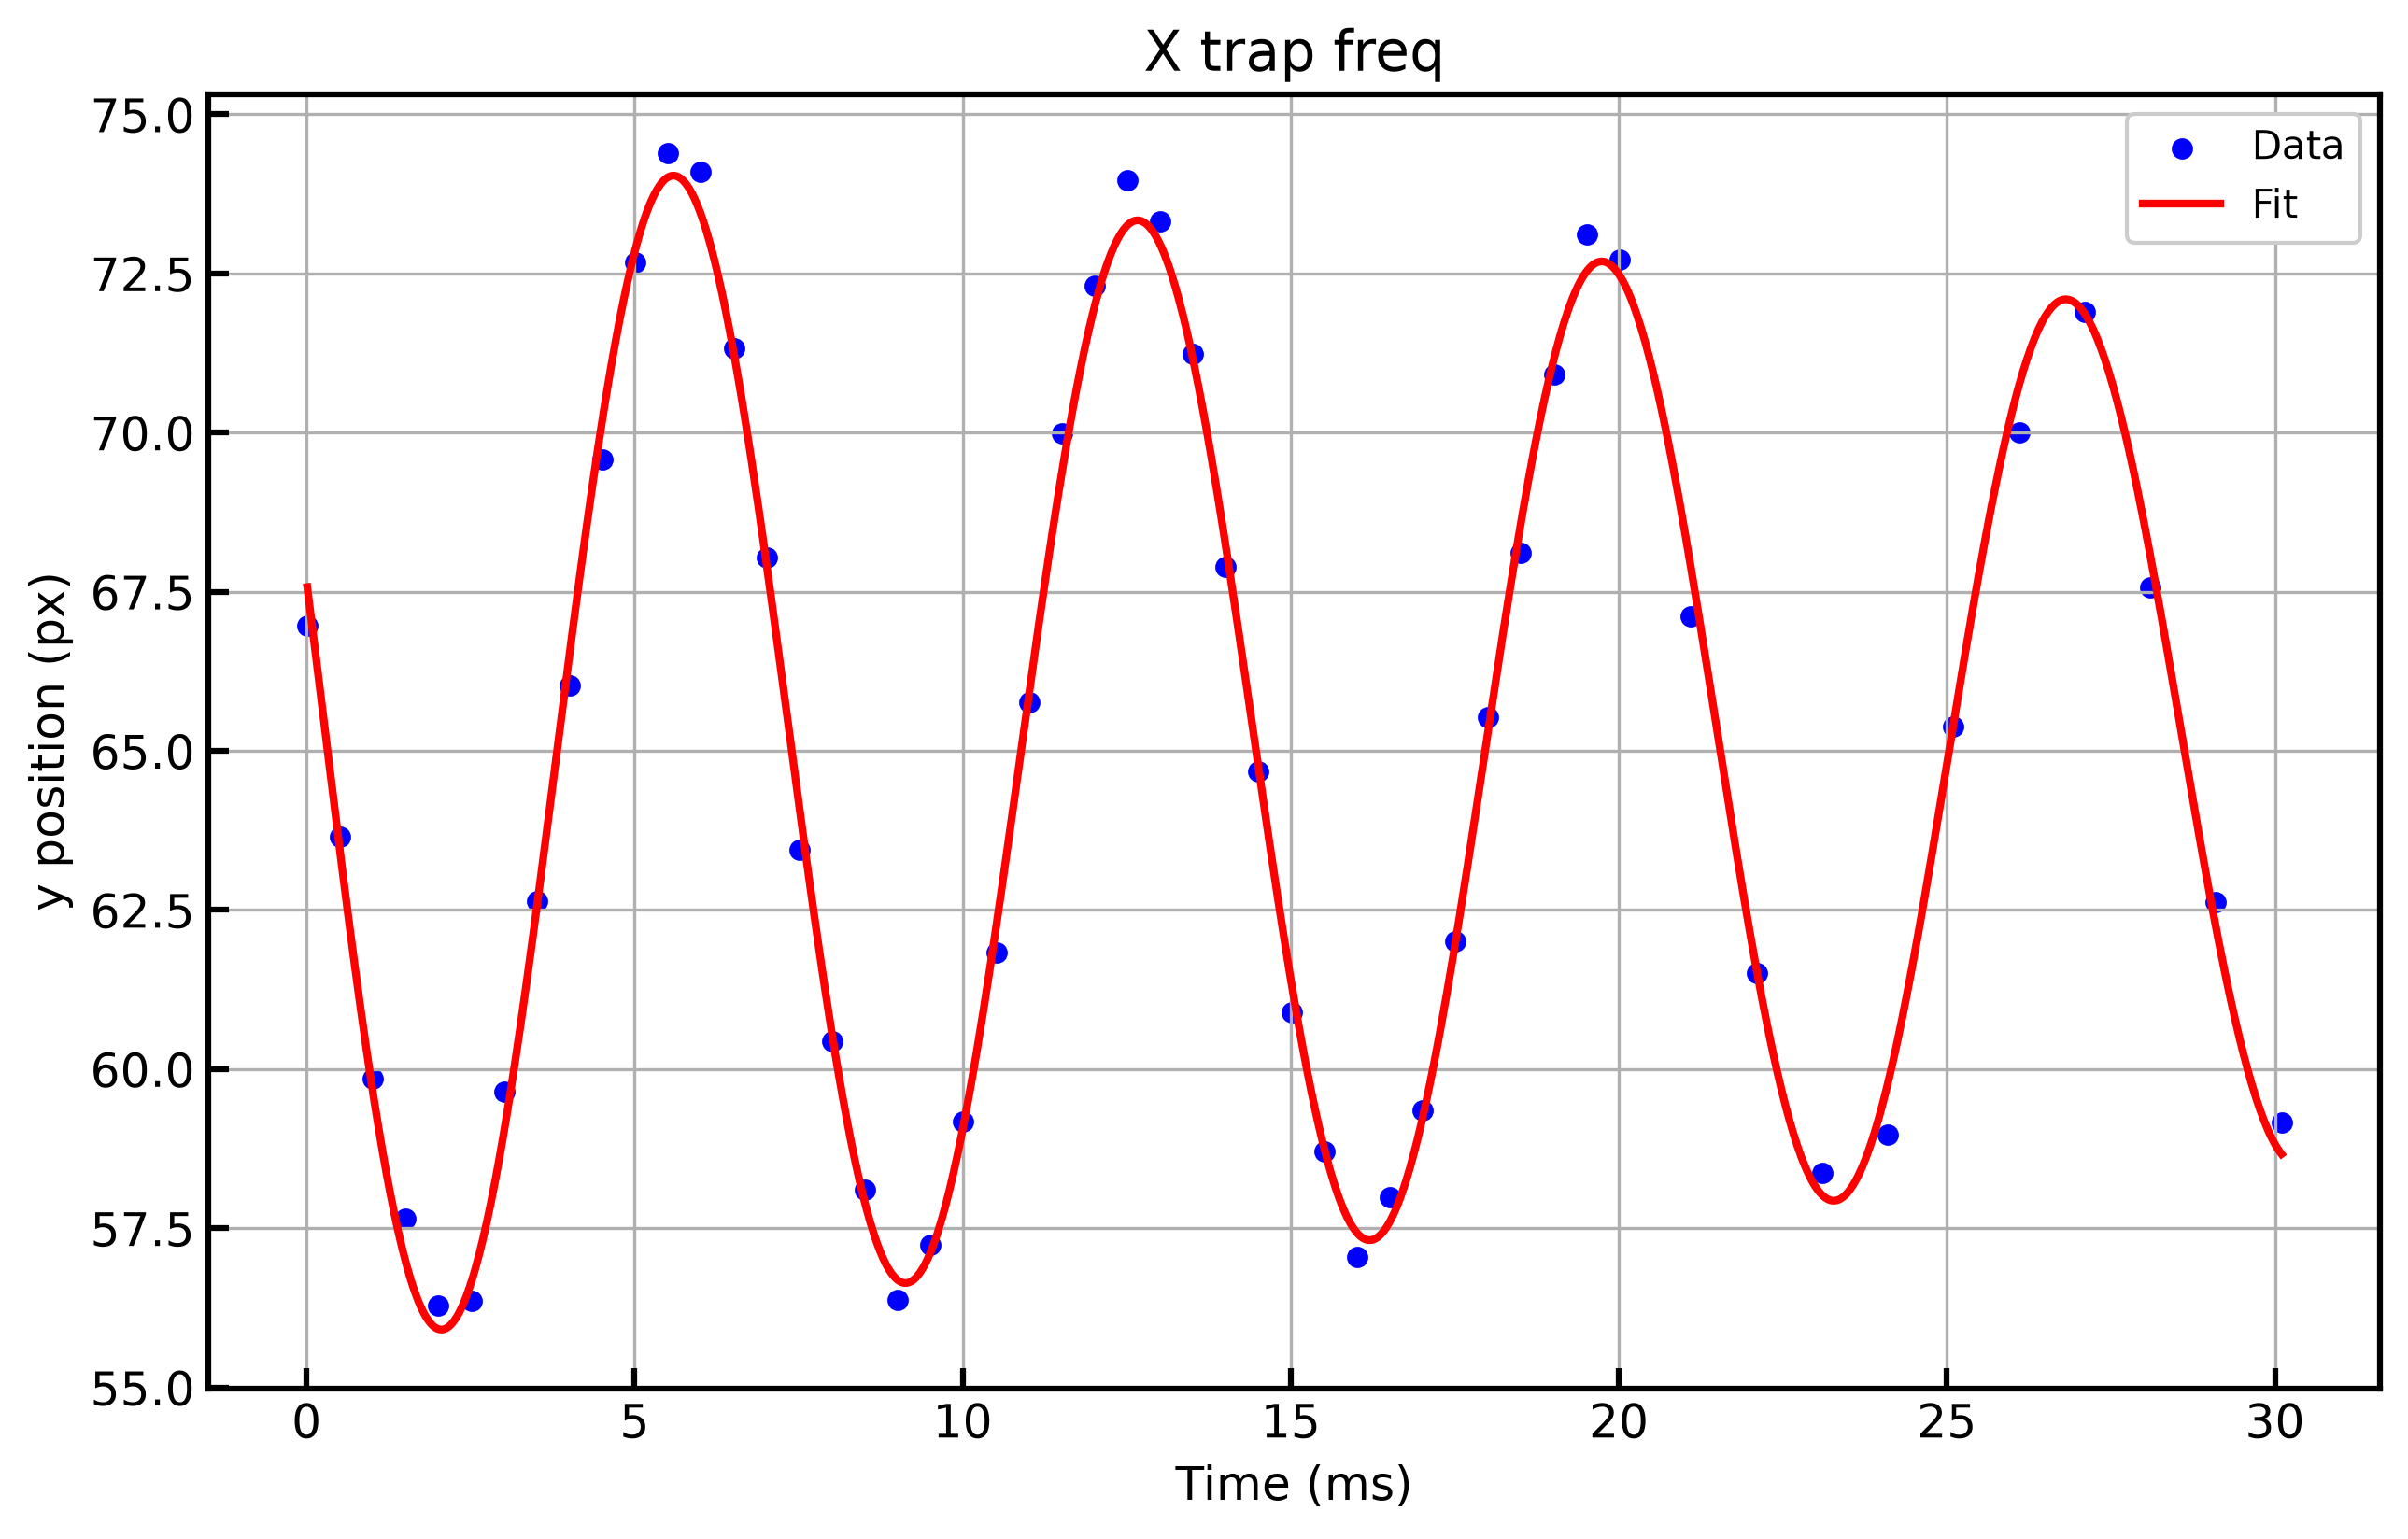

The frequency of oscillation is 0.1414(2) kHz
The decay time is 85.9242(9986) ms


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data', color='blue', s=20)
x_fit = np.linspace(x.min(), x.max(), 1000)
plt.plot(x_fit, trap_freq_func(x_fit, *popt), '-', label='Fit', color='red')
plt.title(title)
plt.xlabel('Time (ms)')
plt.ylabel('y position (px)')
plt.legend()
plt.grid()
plt.show()

print("The frequency of oscillation is {:.4f}({:.0f}) kHz".format(popt[2], 1e4*perr[2]))
print("The decay time is {:.4f}({:.0f}) ms".format(popt[1], 1e3*perr[1]))
print("omegatau = {:.4f}({:.0f})".format(popt[2]*popt[1], 1e4*np.sqrt((perr[2]/popt[2])**2 + (perr[1]/popt[1])**2)))